<a href="https://colab.research.google.com/github/NiroNithy/Personal_Portfolio/blob/Research/People's_ANN_Lime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=fe5eb29a5dbca91eb0b365338a74c32d26a5a7291afa27012773b8d52e5fb482
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
#LOAD THE DATA
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

df=pd.read_csv('/content/PeopleBank Dataset.csv',encoding='ISO-8859-1')
df

,content,at,appVersion
0,"After the recent update, I can't use the app. ...",2025-01-25T06:58:49,V 1.36.1.2
1,"Shows me a message after the latest update. ""T...",2025-01-25T06:12:57,V 1.36.1.2
2,Not opening without finger print. My phone is ...,2025-01-25T03:05:31,V 1.36.1.2
3,I updated this app on 25 th January 2025. Afte...,2025-01-25T01:09:05,V 1.36.1.2
4,Every time Unable connect server what's this ð...,2025-01-23T12:39:13,V 1.34.1.2
...,...,...,...
915,Super,2022-01-18T06:42:34,V 1.24.1.2
916,Register step 3 problem,2022-01-17T09:37:47,V 1.24.1.2
917,Too much authentication,2022-01-14T23:48:56,V 1.24.1.2
918,"Transaction confirmation pdf not received. So,...",2022-01-11T07:04:08,V 1.24.1.2


In [ ]:
# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Preprocessing function
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    words = word_tokenize(text.lower())  # Tokenize and convert to lowercase
    return ' '.join(word for word in words if word.isalnum() and word not in stop_words)

In [ ]:
# Apply preprocessing to the content column
df['cleaned_content'] = df['content'].apply(preprocess_text)

In [ ]:
df

,content,at,appVersion,cleaned_content
0,"After the recent update, I can't use the app. ...",2025-01-25T06:58:49,V 1.36.1.2,recent update ca use app keep showing device a...
1,"Shows me a message after the latest update. ""T...",2025-01-25T06:12:57,V 1.36.1.2,shows message latest update device app signatu...
2,Not opening without finger print. My phone is ...,2025-01-25T03:05:31,V 1.36.1.2,opening without finger print phone available f...
3,I updated this app on 25 th January 2025. Afte...,2025-01-25T01:09:05,V 1.36.1.2,updated app 25 th january open app message app...
4,Every time Unable connect server what's this ð...,2025-01-23T12:39:13,V 1.34.1.2,every time unable connect server
...,...,...,...,...
915,Super,2022-01-18T06:42:34,V 1.24.1.2,super
916,Register step 3 problem,2022-01-17T09:37:47,V 1.24.1.2,register step 3 problem
917,Too much authentication,2022-01-14T23:48:56,V 1.24.1.2,much authentication
918,"Transaction confirmation pdf not received. So,...",2022-01-11T07:04:08,V 1.24.1.2,transaction confirmation pdf received prove so...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
#Initialize VADER Sentiment Analyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
sia = SentimentIntensityAnalyzer()

In [ ]:
#Take Sentiment Score
def classify_sentiment(score):
  if score >= 0.05:
    return 'positive'
  elif score <= 0.05:
    return 'negative'
  else:
    return 'netural'

#new output column as sentiment score(value)
df['sentiment_score'] = df['content'].apply(lambda x:sia.polarity_scores(x)['compound'])
df['sentiment'] = df['sentiment_score'].apply(classify_sentiment)

In [ ]:
df

,content,at,appVersion,cleaned_content,sentiment_score,sentiment
0,"After the recent update, I can't use the app. ...",2025-01-25T06:58:49,V 1.36.1.2,recent update ca use app keep showing device a...,0.3182,positive
1,"Shows me a message after the latest update. ""T...",2025-01-25T06:12:57,V 1.36.1.2,shows message latest update device app signatu...,0.0000,negative
2,Not opening without finger print. My phone is ...,2025-01-25T03:05:31,V 1.36.1.2,opening without finger print phone available f...,0.0000,negative
3,I updated this app on 25 th January 2025. Afte...,2025-01-25T01:09:05,V 1.36.1.2,updated app 25 th january open app message app...,0.3182,positive
4,Every time Unable connect server what's this ð...,2025-01-23T12:39:13,V 1.34.1.2,every time unable connect server,0.0000,negative
...,...,...,...,...,...,...
915,Super,2022-01-18T06:42:34,V 1.24.1.2,super,0.5994,positive
916,Register step 3 problem,2022-01-17T09:37:47,V 1.24.1.2,register step 3 problem,-0.4019,negative
917,Too much authentication,2022-01-14T23:48:56,V 1.24.1.2,much authentication,0.0000,negative
918,"Transaction confirmation pdf not received. So,...",2022-01-11T07:04:08,V 1.24.1.2,transaction confirmation pdf received prove so...,0.0000,negative


In [ ]:
#Filter rows with negative sentiment
negative_reviews = df[df['sentiment'] == 'negative']

In [ ]:
negative_reviews

,content,at,appVersion,cleaned_content,sentiment_score,sentiment
1,"Shows me a message after the latest update. ""T...",2025-01-25T06:12:57,V 1.36.1.2,shows message latest update device app signatu...,0.0000,negative
2,Not opening without finger print. My phone is ...,2025-01-25T03:05:31,V 1.36.1.2,opening without finger print phone available f...,0.0000,negative
4,Every time Unable connect server what's this ð...,2025-01-23T12:39:13,V 1.34.1.2,every time unable connect server,0.0000,negative
6,Always app is not working.It says server timeout,2025-01-21T05:26:13,V 1.34.1.2,always app says server timeout,0.0000,negative
8,"Sometimes when using it, its functionality doe...",2025-01-13T08:15:39,V 1.34.1.2,sometimes using functionality seem work unable...,0.0000,negative
...,...,...,...,...,...,...
911,"After we transfer to money to other account,ca...",2022-01-25T08:25:56,V 1.24.1.2,transfer money account ca download responsible,-0.2411,negative
912,I am using my mobile phone to connect. But eve...,2022-01-24T03:14:41,V 1.24.1.2,using mobile phone connect everytime trying lo...,0.0000,negative
916,Register step 3 problem,2022-01-17T09:37:47,V 1.24.1.2,register step 3 problem,-0.4019,negative
917,Too much authentication,2022-01-14T23:48:56,V 1.24.1.2,much authentication,0.0000,negative


In [ ]:
# Convert text to a TF-IDF representation
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
tfidf_dtm = tfidf_vectorizer.fit_transform(negative_reviews['cleaned_content'])

In [ ]:
# Apply LDA for topic modeling
lda = LatentDirichletAllocation(n_components=2, random_state=42)  # Assume 2 topics (UI, UX)
lda.fit(tfidf_dtm)

LatentDirichletAllocation(n_components=2, random_state=42)

In [ ]:
# Extract keywords for each topic
def get_top_keywords(model, feature_names, n_top_words):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        topics[f"Topic {topic_idx + 1}"] = [feature_names[i] for i in topic.argsort()[-n_top_words:]]
    return topics

n_top_words = 20
feature_names = tfidf_vectorizer.get_feature_names_out()
topics = get_top_keywords(lda, feature_names, n_top_words)

In [ ]:
print("Identified Topics with Keywords:")
for topic, keywords in topics.items():
   print(f"{topic}: {', '.join(keywords)}")

Identified Topics with Keywords:
Topic 1: useless, need, screenshot, transaction, poor, banking, change, open, friendly, service, login, slow, bank, user, ca, time, password, bad, worst, app
Topic 2: error, screen, wasting, payment, people, naic, time, mobile, usefull, properly, account, work, app, new, log, connect, server, unable, update, working


In [ ]:
#Assign the most probable topic to each review
negative_reviews['topic'] = lda.transform(tfidf_dtm).argmax(axis=1)

<ipython-input-19-1c6ee9867e2a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_reviews['topic'] = lda.transform(tfidf_dtm).argmax(axis=1)


In [ ]:
# Map topic numbers to labels
topic_labels = {0: 'UI', 1: 'UX'}
negative_reviews['classification'] = negative_reviews['topic'].map(topic_labels)

<ipython-input-20-6f27e2f65528>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_reviews['classification'] = negative_reviews['topic'].map(topic_labels)


In [ ]:
negative_reviews

,content,at,appVersion,cleaned_content,sentiment_score,sentiment,topic,classification
1,"Shows me a message after the latest update. ""T...",2025-01-25T06:12:57,V 1.36.1.2,shows message latest update device app signatu...,0.0000,negative,1,UX
2,Not opening without finger print. My phone is ...,2025-01-25T03:05:31,V 1.36.1.2,opening without finger print phone available f...,0.0000,negative,1,UX
4,Every time Unable connect server what's this ð...,2025-01-23T12:39:13,V 1.34.1.2,every time unable connect server,0.0000,negative,1,UX
6,Always app is not working.It says server timeout,2025-01-21T05:26:13,V 1.34.1.2,always app says server timeout,0.0000,negative,0,UI
8,"Sometimes when using it, its functionality doe...",2025-01-13T08:15:39,V 1.34.1.2,sometimes using functionality seem work unable...,0.0000,negative,1,UX
...,...,...,...,...,...,...,...,...
911,"After we transfer to money to other account,ca...",2022-01-25T08:25:56,V 1.24.1.2,transfer money account ca download responsible,-0.2411,negative,0,UI
912,I am using my mobile phone to connect. But eve...,2022-01-24T03:14:41,V 1.24.1.2,using mobile phone connect everytime trying lo...,0.0000,negative,1,UX
916,Register step 3 problem,2022-01-17T09:37:47,V 1.24.1.2,register step 3 problem,-0.4019,negative,0,UI
917,Too much authentication,2022-01-14T23:48:56,V 1.24.1.2,much authentication,0.0000,negative,1,UX


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
#from lime.lime_text import LimeTextExplainer

In [ ]:
# Split the data into training and testing sets
X = tfidf_dtm.toarray()
Y = negative_reviews['classification'].apply(lambda x: 0 if x == 'UI' else 1)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Ensure X and Y are NumPy arrays
X = np.array(X)  # Convert X to a NumPy array if it isn't already
Y = np.array(Y)  # Convert Y to a NumPy array if it isn't already

import random
import tensorflow as tf

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

def build_ann(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_dim=input_dim))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Build and train the ANN model
ann = build_ann(X.shape[1])
ann.fit(X_train, Y_train, epochs=50, batch_size=32, verbose=0)  # Adjust epochs and batch size as needed

# Predict on the test set
Y_pred = (ann.predict(X_test) > 0.5).astype(int).flatten()

# Calculate Accuracy
accuracy = accuracy_score(Y_test, Y_pred)

# Calculate MSE (Mean Squared Error)
mse = mean_squared_error(Y_test, Y_pred)

# Print results
print(f"ANN Accuracy: {accuracy:.2f}")
print(f"ANN Mean Squared Error (MSE): {mse:.2f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
ANN Accuracy: 0.90
ANN Mean Squared Error (MSE): 0.10


In [ ]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# Classification report
print(classification_report(Y_test, Y_pred, target_names=['UI', 'UX']))

# Or individual scores
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

              precision    recall  f1-score   support

          UI       0.88      0.98      0.93        62
          UX       0.95      0.71      0.82        28

    accuracy                           0.90        90
   macro avg       0.92      0.85      0.87        90
weighted avg       0.91      0.90      0.90        90

Precision: 0.95
Recall: 0.71
F1 Score: 0.82


In [ ]:
import collections

# Count labels
print("Train set distribution:", collections.Counter(Y_train))
print("Test set distribution:", collections.Counter(Y_test))

Train set distribution: Counter({0: 251, 1: 109})
Test set distribution: Counter({0: 62, 1: 28})


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


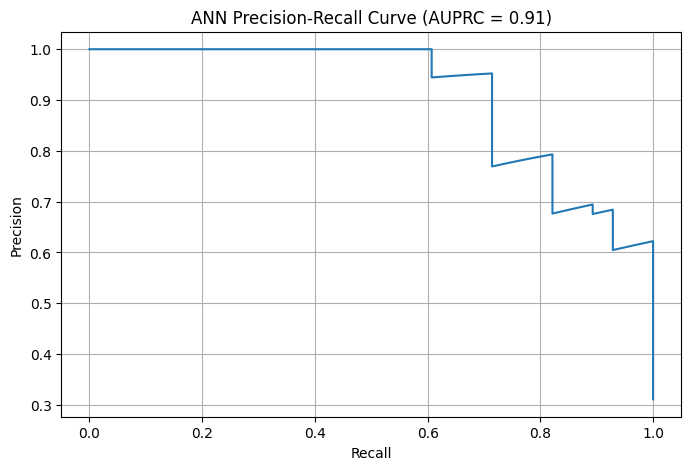

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Get prediction probabilities (before thresholding)
Y_probs = ann.predict(X_test).flatten()

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(Y_test, Y_probs)
auprc = average_precision_score(Y_test, Y_probs)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 5))
plt.plot(recall, precision)
plt.title(f'ANN Precision-Recall Curve (AUPRC = {auprc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

In [ ]:
# Define LIME explainer
explainer = LimeTextExplainer(class_names=['UI', 'UX'])

# Convert TF-IDF back to text for LIME
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

def predict_fn(text_list):
    # Transform text to TF-IDF
    tfidf_matrix = tfidf_vectorizer.transform(text_list).toarray()

    # Use the trained ANN model (ann) to get predictions
    predictions = ann.predict(tfidf_matrix)  # Use the 'ann' model that is already defined

    # Return probabilities for both classes (UI and UX)
    return np.hstack([1 - predictions, predictions])

# Select a random review from the test set
sample_index = 30
sample_text = negative_reviews.iloc[sample_index]['cleaned_content']
print(f"Review Text: {sample_text}")

# Explain model prediction
exp = explainer.explain_instance(sample_text, predict_fn, num_features=10)
exp.show_in_notebook()

Review Text: fingerprint login option stopped working recently
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


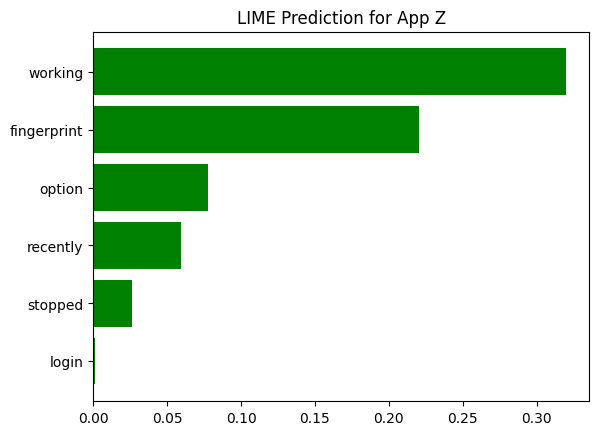

In [ ]:
import matplotlib.pyplot as plt

# Save LIME explanation as an image
fig = exp.as_pyplot_figure()

# Update the title of the plot
plt.title("LIME Prediction for App Z")

# Save the figure with the updated title
fig.savefig("LIME_prediction_graph.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Define the sample review text (same one used in LIME explanation)
sample_review = negative_reviews.iloc[sample_index]['cleaned_content']
print(f"Review Text: {sample_review}")

# Convert the sample review text into TF-IDF format for ANN prediction
sample_tfidf = tfidf_vectorizer.transform([sample_review]).toarray()

# Predict the class using the ANN model
ann_prediction = ann.predict(sample_tfidf)  # ANN model prediction
predicted_label = (ann_prediction > 0.5).astype(int)  # Convert to binary prediction (0 or 1)

# Define the class labels (UI and UX)
class_labels = {0: 'UI', 1: 'UX'}

# Get the ANN model's predicted classification
model_classification = class_labels[predicted_label[0][0]]
print(f"ANN Model Prediction: {model_classification}")

# Now, run LIME's explanation for this review
exp = explainer.explain_instance(sample_review, predict_fn, num_features=10)

# Show the explanation in the notebook
exp.show_in_notebook()

# Optionally, you can compare the LIME output with the ANN prediction
print(f"LIME model's predicted classification (based on explanation): {model_classification}")

Review Text: fingerprint login option stopped working recently
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
ANN Model Prediction: UX
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


LIME model's predicted classification (based on explanation): UX


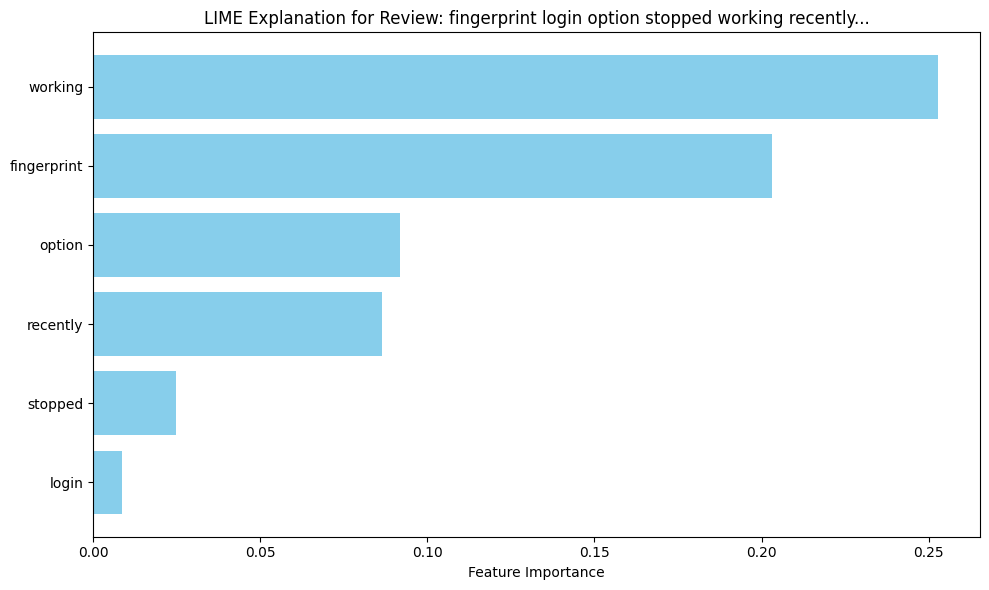

ANN Model Prediction: UX


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract the LIME explanation
# Get the top features and their importance (weights)
lime_features = exp.as_list()  # Get the features and their importance
features, importances = zip(*lime_features)  # Unzip into features and importance

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(features[:10], importances[:10], color='skyblue')  # Top 10 important features
plt.xlabel('Feature Importance')
plt.title(f"LIME Explanation for Review: {sample_review[:50]}...")  # Show a snippet of the review
plt.gca().invert_yaxis()  # To have the highest importance at the top
plt.tight_layout()
plt.show()

# Display the ANN prediction result
print(f"ANN Model Prediction: {model_classification}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.7148 - loss: 0.6882 - val_accuracy: 0.6889 - val_loss: 0.6752
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7165 - loss: 0.6624 - val_accuracy: 0.6889 - val_loss: 0.6534
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7007 - loss: 0.6331 - val_accuracy: 0.6889 - val_loss: 0.6262
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6941 - loss: 0.5938 - val_accuracy: 0.6889 - val_loss: 0.5938
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6968 - loss: 0.5451 - val_accuracy: 0.6889 - val_loss: 0.5575
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7252 - loss: 0.4878 - val_accuracy: 0.7111 - val_loss: 0.5183
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7771 - loss: 0.4213 - val_accuracy: 0.7444 - val_loss: 0.4767
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8560 - loss: 0.3483 - val_accuracy: 0.

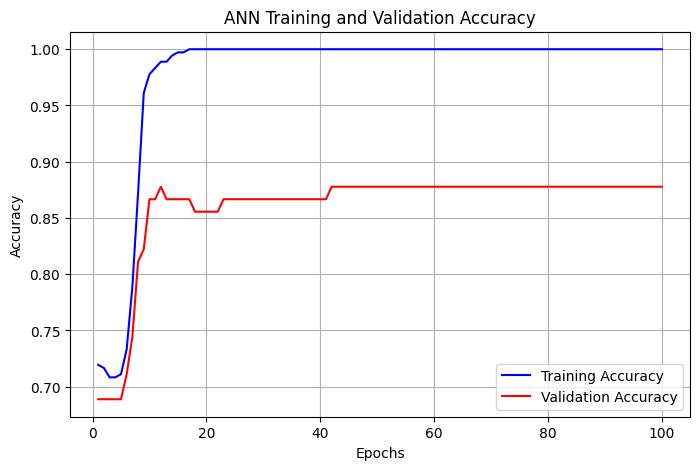

In [ ]:
import matplotlib.pyplot as plt

# Train the ANN model and store the training history
ann = build_ann(X.shape[1])
history = ann.fit(X_train, Y_train, epochs=100, batch_size=32, validation_data=(X_test, Y_test), verbose=1)

# Extract accuracy values from history
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(train_acc) + 1)

# Plot Training & Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label='Training Accuracy', color='blue')
plt.plot(epochs, val_acc, label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('ANN Training and Validation Accuracy')
plt.legend()
plt.grid()
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


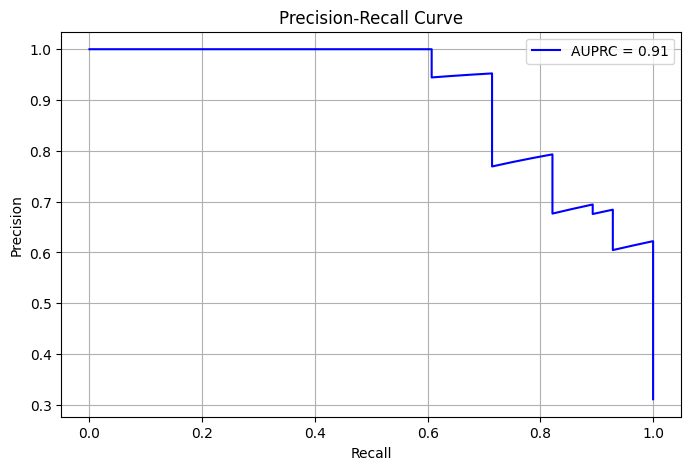

In [ ]:
from sklearn.metrics import precision_recall_curve, auc

# Get model predictions (probabilities)
Y_prob = ann.predict(X_test)  # ANN outputs probabilities

# Compute Precision-Recall curve
precision, recall, _ = precision_recall_curve(Y_test, Y_prob)

# Compute Area Under the Precision-Recall Curve (AUPRC)
auprc = auc(recall, precision)

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='blue', label=f'AUPRC = {auprc:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Prepare data
X = tfidf_dtm.toarray()
Y = negative_reviews['classification'].apply(lambda x: 0 if x == 'UI' else 1)

X = np.array(X)
Y = np.array(Y)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Build ANN model with stronger regularization and batch normalization
def build_ann(input_dim):
    model = Sequential()
    model.add(Dense(16, activation='relu', input_dim=input_dim,
                    kernel_regularizer=regularizers.l1_l2(0.1)))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    model.add(Dense(8, activation='relu',
                    kernel_regularizer=regularizers.l1_l2(0.1)))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    model.add(Dense(1, activation='sigmoid'))  # Binary output
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.4111 - loss: 33.5053 - val_accuracy: 0.6667 - val_loss: 29.5941
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4488 - loss: 28.6686 - val_accuracy: 0.6333 - val_loss: 25.2130
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5267 - loss: 24.3212 - val_accuracy: 0.6667 - val_loss: 21.2560
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4957 - loss: 20.4838 - val_accuracy: 0.6889 - val_loss: 17.6955
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5495 - loss: 16.9537 - val_accuracy: 0.6889 - val_loss: 14.5279
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5095 - loss: 13.9972 - val_accuracy: 0.6889 - val_loss: 11.7755
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6244 - loss: 11.2292 - val_accuracy: 0.6889 - val_loss: 9.4278
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6052 - loss: 8.9331 - val_accuracy: 0

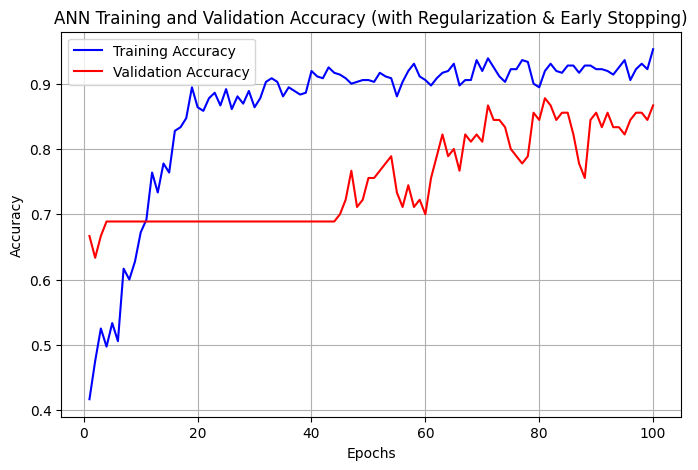

In [ ]:
# Train the model
ann = build_ann(X.shape[1])
history = ann.fit(X_train, Y_train, epochs=100, batch_size=32,
                  validation_data=(X_test, Y_test),
                  callbacks=[early_stop],
                  verbose=1)

# Predict and evaluate
Y_pred = (ann.predict(X_test) > 0.5).astype(int).flatten()

accuracy = accuracy_score(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

# Print results
print(f"ANN Accuracy: {accuracy:.2f}")
print(f"ANN Mean Squared Error (MSE): {mse:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(classification_report(Y_test, Y_pred, target_names=['UI', 'UX']))

# Plot Training & Validation Accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label='Training Accuracy', color='blue')
plt.plot(epochs, val_acc, label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('ANN Training and Validation Accuracy (with Regularization & Early Stopping)')
plt.legend()
plt.grid()
plt.show()